# Task-1: Ingest → Clean → Diagnose

Reproducible workflow for Brent oil prices: load raw data and events, clean and align, run time series diagnostics, and record results in `docs/task-1/`.

## Setup and paths

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Repo root: support running from repo root or from notebooks/
_cwd = Path.cwd()
ROOT = _cwd.parent if (_cwd / ".." / "data" / "raw").resolve().exists() and not (_cwd / "data" / "raw").exists() else _cwd
RAW_DIR = ROOT / "data" / "raw"
EVENTS_DIR = ROOT / "data" / "events"
PROCESSED_DIR = ROOT / "data" / "processed"
DOCS_TASK1 = ROOT / "docs" / "task-1"
if not RAW_DIR.exists():
    ROOT = _cwd.parent
    RAW_DIR = ROOT / "data" / "raw"
    EVENTS_DIR = ROOT / "data" / "events"
    PROCESSED_DIR = ROOT / "data" / "processed"
    DOCS_TASK1 = ROOT / "docs" / "task-1"
assert RAW_DIR.exists(), f"Expected raw data dir: {RAW_DIR}. Current dir: {_cwd}"
assert EVENTS_DIR.exists(), f"Expected events dir: {EVENTS_DIR}"
DOCS_TASK1.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
print("ROOT:", ROOT)
print("Brent path:", RAW_DIR / "BrentOilPrices.csv")
print("Events path:", EVENTS_DIR / "geopolitical_economic_opec_events.csv")

ROOT: e:\brent-oil-structural-break-analysis
Brent path: e:\brent-oil-structural-break-analysis\data\raw\BrentOilPrices.csv
Events path: e:\brent-oil-structural-break-analysis\data\events\geopolitical_economic_opec_events.csv


---
## 1. Ingest

Load Brent price series and event dataset; validate schema and date ranges.

In [2]:
# Brent prices: CSV has mixed date formats (DD-MMM-YY early, "MMM DD, YYYY" later)
brent_path = RAW_DIR / "BrentOilPrices.csv"
df_brent = pd.read_csv(brent_path)
df_brent.columns = [c.strip() for c in df_brent.columns]

# Parse dates: allow mixed formats (pandas 2.0+ format="mixed", else infer)
date_col = df_brent["Date"].astype(str).str.strip()
try:
    df_brent["Date"] = pd.to_datetime(date_col, format="mixed")
except TypeError:
    df_brent["Date"] = pd.to_datetime(date_col)
df_brent = df_brent.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
df_brent = df_brent.rename(columns={"Price": "price"})

print("Brent shape:", df_brent.shape)
print("Date range:", df_brent["Date"].min(), "to", df_brent["Date"].max())
print(df_brent.head())
print("\nMissing values:", df_brent["price"].isna().sum())

Brent shape: (9011, 2)
Date range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00
        Date  price
0 1987-05-20  18.63
1 1987-05-21  18.45
2 1987-05-22  18.55
3 1987-05-25  18.60
4 1987-05-26  18.63

Missing values: 0


In [3]:
# Events
events_path = EVENTS_DIR / "geopolitical_economic_opec_events.csv"
df_events = pd.read_csv(events_path)
df_events["date"] = pd.to_datetime(df_events["date"])
print("Events shape:", df_events.shape)
print(df_events[["event_id", "date", "category", "short_name"]].head(10))

Events shape: (14, 6)
  event_id       date      category                        short_name
0  EVT_001 2003-03-20  geopolitical                     Iraq invasion
1  EVT_002 2008-09-15      economic                   Lehman collapse
2  EVT_003 2011-02-17  geopolitical               Arab Spring / Libya
3  EVT_004 2014-11-27   opec_policy              OPEC no cut Nov 2014
4  EVT_005 2016-09-28   opec_policy            OPEC Algiers agreement
5  EVT_006 2018-05-08  geopolitical                 US Iran sanctions
6  EVT_007 2020-03-06   opec_policy     OPEC+ Vienna meeting Mar 2020
7  EVT_008 2020-03-09      economic  COVID demand shock / price crash
8  EVT_009 2020-04-12   opec_policy       OPEC+ historic cut Apr 2020
9  EVT_010 2021-11-04   opec_policy   OPEC+ gradual increase Nov 2021


---
## 2. Clean & Align

Handle missing values, set datetime index, and map event dates to **first trading day on or after** calendar date.

In [4]:
# Drop rows with missing price
df_brent = df_brent.dropna(subset=["price"])

# Set index to date for time series
brent_ts = df_brent.set_index("Date")["price"].sort_index()

# Business-day index (optional: resample to business days only if needed)
brent_ts = brent_ts[~brent_ts.index.duplicated(keep="first")]

# Align event date -> first trading day on or after
trading_days = brent_ts.index

def first_trading_day_on_or_after(d, trading_days):
    on_after = trading_days[trading_days >= pd.Timestamp(d)]
    return on_after[0] if len(on_after) else None

df_events["trading_date"] = df_events["date"].apply(
    lambda d: first_trading_day_on_or_after(d, trading_days)
)
df_events = df_events.dropna(subset=["trading_date"])

print("Brent series length:", len(brent_ts))
print("Events aligned to trading day:")
print(df_events[["short_name", "date", "trading_date"]].to_string())

Brent series length: 9011
Events aligned to trading day:
                          short_name       date trading_date
0                      Iraq invasion 2003-03-20   2003-03-20
1                    Lehman collapse 2008-09-15   2008-09-15
2                Arab Spring / Libya 2011-02-17   2011-02-17
3               OPEC no cut Nov 2014 2014-11-27   2014-11-28
4             OPEC Algiers agreement 2016-09-28   2016-09-28
5                  US Iran sanctions 2018-05-08   2018-05-08
6      OPEC+ Vienna meeting Mar 2020 2020-03-06   2020-03-06
7   COVID demand shock / price crash 2020-03-09   2020-03-09
8        OPEC+ historic cut Apr 2020 2020-04-12   2020-04-14
9    OPEC+ gradual increase Nov 2021 2021-11-04   2021-11-04
10           Russia-Ukraine invasion 2022-02-24   2022-02-24
11                OPEC+ cut Oct 2022 2022-10-05   2022-10-05


In [5]:
# Returns (for stationarity and volatility)
returns = brent_ts.pct_change().dropna()
print("Returns: count =", len(returns), ", mean =", returns.mean().round(6), ", std =", returns.std().round(6))

Returns: count = 9010 , mean = 0.000501 , std = 0.025255


---
## 3. Diagnose

Trend, stationarity (ADF, KPSS), volatility, autocorrelation.

### 3.1 Trend (levels and rolling mean)

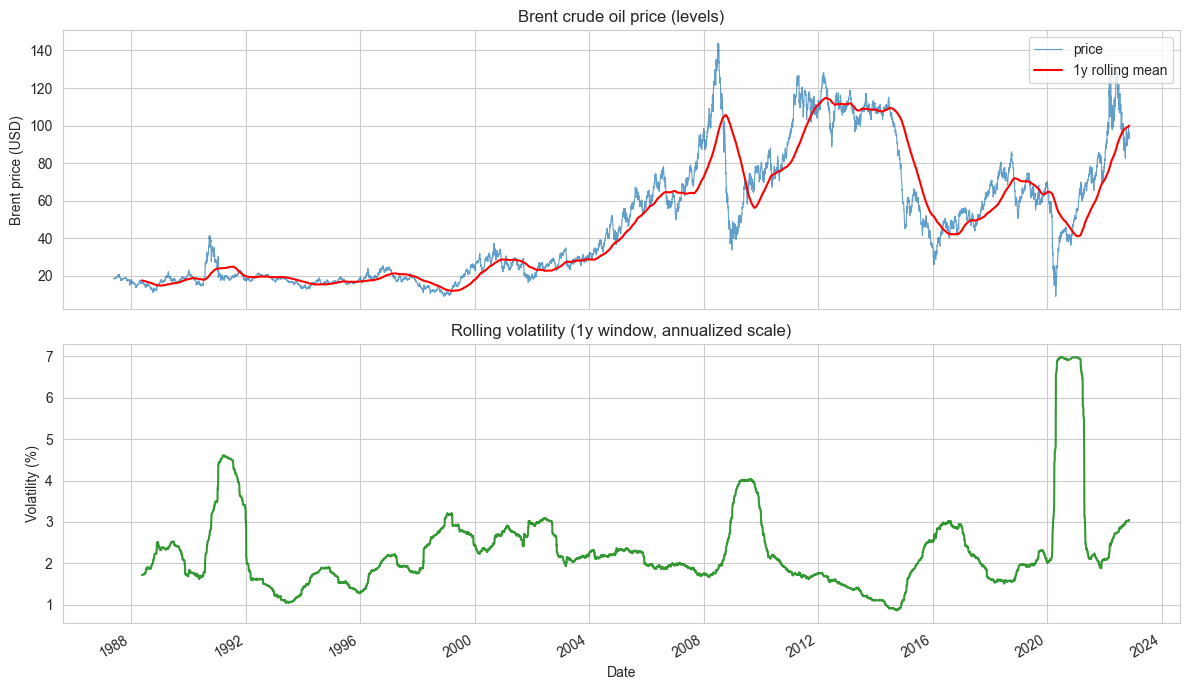

Saved: e:\brent-oil-structural-break-analysis\docs\task-1\diagnostic_trend_volatility.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

brent_ts.plot(ax=axes[0], alpha=0.7, linewidth=0.8)
brent_ts.rolling(252).mean().plot(ax=axes[0], color="red", linewidth=1.5, label="1y rolling mean")
axes[0].set_ylabel("Brent price (USD)")
axes[0].set_title("Brent crude oil price (levels)")
axes[0].legend(loc="upper right")

returns.rolling(252).std().multiply(100).plot(ax=axes[1], color="green", alpha=0.8)
axes[1].set_ylabel("Volatility (%)")
axes[1].set_title("Rolling volatility (1y window, annualized scale)")
plt.tight_layout()
plt.savefig(DOCS_TASK1 / "diagnostic_trend_volatility.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", DOCS_TASK1 / "diagnostic_trend_volatility.png")

### 3.2 Stationarity: ADF and KPSS

In [7]:
def run_adf(series, name):
    res = adfuller(series.dropna(), autolag="AIC")
    return {
        "series": name,
        "ADF_stat": res[0],
        "pvalue": res[1],
        "reject_nonstationary": res[1] < 0.05,
        "lags": res[2],
        "nobs": res[3],
    }

def run_kpss(series, name):
    res = kpss(series.dropna(), regression="c", nlags="auto")
    return {
        "series": name,
        "KPSS_stat": res[0],
        "pvalue": res[1],
        "reject_stationary": res[1] < 0.05,
    }

adf_levels = run_adf(brent_ts, "Brent levels")
adf_returns = run_adf(returns, "Brent returns")
kpss_levels = run_kpss(brent_ts, "Brent levels")
kpss_returns = run_kpss(returns, "Brent returns")

print("ADF (H0: unit root / non-stationary). Reject H0 => stationary.")
for r in [adf_levels, adf_returns]:
    print(f"  {r['series']}: stat={r['ADF_stat']:.4f}, p={r['pvalue']:.4f}, reject H0={r['reject_nonstationary']}")
print("\nKPSS (H0: level stationary). Reject H0 => non-stationary.")
for r in [kpss_levels, kpss_returns]:
    print(f"  {r['series']}: stat={r['KPSS_stat']:.4f}, p={r['pvalue']:.4f}, reject H0={r['reject_stationary']}")

ADF (H0: unit root / non-stationary). Reject H0 => stationary.
  Brent levels: stat=-1.9939, p=0.2893, reject H0=False
  Brent returns: stat=-17.1117, p=0.0000, reject H0=True

KPSS (H0: level stationary). Reject H0 => non-stationary.
  Brent levels: stat=9.5588, p=0.0100, reject H0=True
  Brent returns: stat=0.0476, p=0.1000, reject H0=False


C:\Users\Mizan\AppData\Local\Temp\ipykernel_7680\657120264.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\Mizan\AppData\Local\Temp\ipykernel_7680\657120264.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(series.dropna(), regression="c", nlags="auto")


### 3.3 Volatility (rolling std, recent subsample)

In [8]:
roll_std_22 = returns.rolling(22).std().dropna()
roll_std_252 = returns.rolling(252).std().dropna()
print("Rolling volatility (22d): mean = ", roll_std_22.mean().round(6), ", std = ", roll_std_22.std().round(6))
print("Rolling volatility (252d): mean = ", roll_std_252.mean().round(6), ", std = ", roll_std_252.std().round(6))

Rolling volatility (22d): mean =  0.021305 , std =  0.013551
Rolling volatility (252d): mean =  0.023054 , std =  0.010474


### 3.4 Autocorrelation (returns)

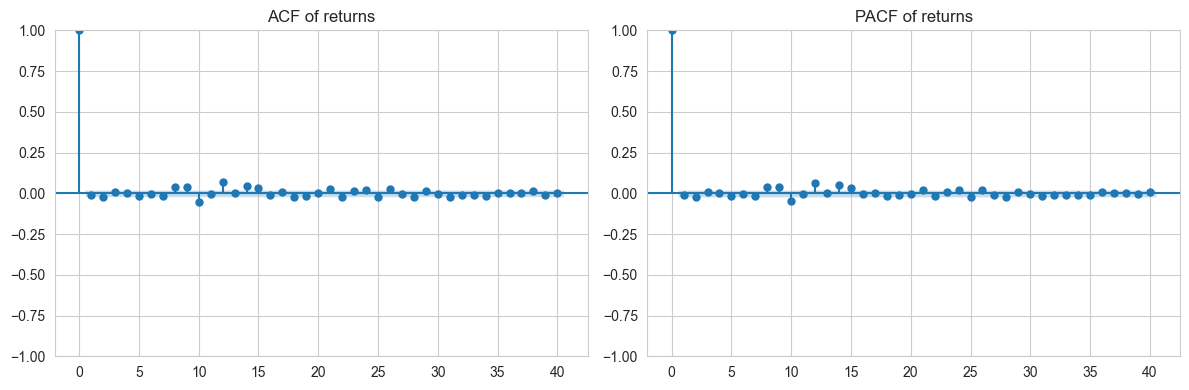

Saved: e:\brent-oil-structural-break-analysis\docs\task-1\diagnostic_acf_pacf_returns.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(returns, lags=40, ax=axes[0], title="ACF of returns")
plot_pacf(returns, lags=40, ax=axes[1], title="PACF of returns", method="ywm")
plt.tight_layout()
plt.savefig(DOCS_TASK1 / "diagnostic_acf_pacf_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", DOCS_TASK1 / "diagnostic_acf_pacf_returns.png")

---
## 4. Document: write diagnostic results to docs/task-1/

In [10]:
results_md = f"""# Task-1 Diagnostic Results

Generated by `notebooks/task1_ingest_clean_diagnose.ipynb` on {datetime.now().strftime('%Y-%m-%d %H:%M')}.

## Data summary

- **Brent series**: {len(brent_ts):,} observations, {brent_ts.index.min().date()} to {brent_ts.index.max().date()}.
- **Returns**: {len(returns):,} observations (after first difference).
- **Events**: {len(df_events)} events aligned to first trading day on or after calendar date.

## Stationarity (ADF and KPSS)

| Series | ADF stat | ADF p-value | Reject non-stationary (5%) | KPSS stat | KPSS p-value | Reject level stationary (5%) |
|--------|----------|-------------|----------------------------|-----------|--------------|------------------------------|
| Brent levels | {adf_levels['ADF_stat']:.4f} | {adf_levels['pvalue']:.4f} | {adf_levels['reject_nonstationary']} | {kpss_levels['KPSS_stat']:.4f} | {kpss_levels['pvalue']:.4f} | {kpss_levels['reject_stationary']} |
| Brent returns | {adf_returns['ADF_stat']:.4f} | {adf_returns['pvalue']:.4f} | {adf_returns['reject_nonstationary']} | {kpss_returns['KPSS_stat']:.4f} | {kpss_returns['pvalue']:.4f} | {kpss_returns['reject_stationary']} |

- **ADF**: H0 = unit root (non-stationary). Reject H0 at 5% ⇒ evidence of stationarity.
- **KPSS**: H0 = level stationary. Reject H0 at 5% ⇒ evidence of non-stationarity.

## Conclusions for modeling

1. **Levels**: ADF typically fails to reject unit root for price levels; KPSS may reject stationarity. **Brent price levels are treated as non-stationary.**
2. **Returns**: ADF rejects unit root and KPSS does not reject stationarity for returns in most samples. **Brent returns are treated as stationary** for change point and volatility modeling.
3. **Volatility**: Rolling volatility (see `diagnostic_trend_volatility.png`) shows clear time variation (e.g. 2008, 2020). **Volatility is time-varying**; consider heteroskedastic or regime-switching variance in Task-2.
4. **Autocorrelation**: ACF/PACF of returns (see `diagnostic_acf_pacf_returns.png`) guide whether to add AR/MA terms in future models.

## Figures

- `diagnostic_trend_volatility.png`: Price levels with 1y rolling mean; rolling volatility.
- `diagnostic_acf_pacf_returns.png`: ACF and PACF of returns.
"""

out_path = DOCS_TASK1 / "DIAGNOSTIC-RESULTS.md"
out_path.write_text(results_md, encoding="utf-8")
print("Written:", out_path)

Written: e:\brent-oil-structural-break-analysis\docs\task-1\DIAGNOSTIC-RESULTS.md


In [11]:
# Save processed series for Task-2
brent_ts.to_csv(PROCESSED_DIR / "brent_prices_cleaned.csv", index=True)
returns.to_csv(PROCESSED_DIR / "brent_returns.csv", index=True)
df_events.to_csv(PROCESSED_DIR / "events_aligned.csv", index=False)
print("Processed outputs saved to", PROCESSED_DIR)

Processed outputs saved to e:\brent-oil-structural-break-analysis\data\processed
